# 6 — Diversification breakdown: a negative result, end to end

**The question.** Can you tell that a portfolio has stopped diversifying *before* the
loss arrives?

The premise is plausible enough to be worth testing: in stress, assets bought to be
different start moving as one, and that coupling might be observable before volatility
spikes. The measurement instrument is the eigenvalue spectrum of the covariance matrix
— not the pairwise correlation matrix, which is N(N-1)/2 numbers moving at once with no
scalar summary of how much of the portfolio is now one trade.

The **absorption ratio** (Kritzman, Li, Page & Rigobon, *Principal Components as a
Measure of Systemic Risk*, J. Portfolio Management 37(4), 2011) is that scalar: the
share of total variance explained by the top `K` eigenvectors.

This notebook walks the whole study, including the part that did not work. The answer
to the question above, on this universe, is **no** — and the interesting content is how
you establish that rather than talking yourself into a yes.

In [1]:
from risk_engine import (
    load_prices, to_returns, portfolio_returns,
    rolling_absorption_ratio, standardised_shift, threshold_crossings,
    drawdown_events, event_study, realised_vol_signal,
    fit_markov_regimes, sensitivity_grid,
)

# 26 US large caps spanning seven sectors. Five tickers would not do: with N=5,
# K = floor(N/5) = 1 and the absorption ratio degenerates to "the first principal
# component", which is a different and much less interesting quantity.
UNIVERSE = [
    "AAPL", "MSFT", "INTC", "IBM", "ORCL", "TXN",
    "JPM", "BAC", "GS", "AXP",
    "JNJ", "PFE", "MRK", "UNH",
    "XOM", "CVX", "SLB",
    "PG", "KO", "WMT", "MCD",
    "CAT", "HON", "UNP",
    "NEE", "SO",
]

returns = to_returns(load_prices(UNIVERSE, start="2007-01-01"))
pnl = portfolio_returns(returns)          # equal weight
print(f"{returns.shape[1]} assets, {len(returns)} days: "
      f"{returns.index[0].date()} to {returns.index[-1].date()}")

26 assets, 4932 days: 2007-01-04 to 2026-08-12


## 1. The absorption ratio, and why the covariance input decides the answer

Two ways to estimate the covariance the ratio is computed from:

- a **rolling sample covariance** over the trailing window, and
- an **EWMA conditional covariance**, which reacts to today's volatility instead of
  averaging the trailing two years. It reuses the same recursion, decay factor and
  seeding convention as the EWMA filter on the VaR side.

This is not a detail. It changes the result more than any other choice in the study.

In [2]:
ewma   = rolling_absorption_ratio(returns, window=500, cov_model="ewma")
sample = rolling_absorption_ratio(returns, window=500, cov_model="sample")

for r in (ewma, sample):
    print(r.summary())

AR[ewma] N=26 K=5 window=500 median=0.7642 min=0.6160 max=0.9723 bets median=8.54
AR[sample] N=26 K=5 window=500 median=0.6906 min=0.5966 max=0.8166 bets median=10.10


## 2. The number that makes it legible: effective bets

The absorption ratio is hard to feel. Its level is set structurally by `N` and `K`, so
"76%" means nothing on its own and cannot be compared across universes.

The **effective number of bets** — the entropy of the normalised eigenvalue spectrum —
is the same information in units anyone can act on. It equals `N` when every eigenvalue
is equal (N genuinely independent risk sources) and falls toward 1 as variance
concentrates into one factor.

In [3]:
bets = ewma.effective_bets
print(f"Holdings                : {ewma.n_assets}")
print(f"Independent bets, calm  : {bets.quantile(0.75):.2f}")
print(f"                 median : {bets.median():.2f}")
print(f"                 stress : {bets.quantile(0.05):.2f}")
print(f"                 minimum: {bets.min():.2f} on {bets.idxmin().date()}")

Holdings                : 26
Independent bets, calm  : 10.13
                 median : 8.54
                 stress : 3.79
                 minimum: 1.86 on 2020-03-17


26 positions behaving like fewer than 2 independent bets at the peak of the March 2020
sell-off. The holdings count never changed; the diversification did.

## 3. Pre-registering the events

Here is where a study like this usually goes wrong. If you pick the "major drawdowns"
*after* looking at the signal, any lead-time claim is unfalsifiable — you will
unconsciously choose the episodes the signal happened to catch.

So the event rule is mechanical, and it was committed to the repository **before** any
absorption output was computed or inspected:

> Compound the equal-weight portfolio into a wealth index. An episode opens when wealth
> falls below the running maximum and closes when a new maximum is reached. Keep
> episodes whose peak-to-trough decline is at least 15%. Onset is the **peak** date —
> the last moment a warning would still have been actionable.

Episodes are non-overlapping by construction: a new one cannot open until the previous
high is recovered. The commit ordering is visible in `git log` — the module and rule
land in one commit, the results in a later one.

In [4]:
events = drawdown_events(pnl, min_depth=0.15)
for e in events:
    print(e)

2007-12-10 -> 2009-03-09  48.0% (455d)
2011-07-07 -> 2011-10-03  16.1% (88d)
2018-09-21 -> 2018-12-24  16.0% (94d)
2020-02-12 -> 2020-03-23  35.0% (40d)
2022-03-30 -> 2022-09-30  15.4% (184d)
2024-11-29 -> 2025-04-08  15.5% (130d)


## 4. The signal is the shift, not the level

The level of AR is structural. The signal is the standardised *change*: a 15-day mean
against a 250-day mean, divided by the long-window standard deviation — the source
paper's construction. Standardising is also what makes the signal invariant to
rescaling returns.

In [5]:
signal    = standardised_shift(ewma.absorption, short=15, long=250)
crossings = threshold_crossings(signal, threshold=1.0)

print(f"Crossings at 1.0 st.dev.: {len(crossings)}")
print(f"First: {crossings[0].date()}   last: {crossings[-1].date()}")

Crossings at 1.0 st.dev.: 20
First: 2010-05-12   last: 2026-05-12


## 5. The event study — with false positives, because a hit rate alone is not a result

Three quantities, all reported:

- **hits** — events flagged by a crossing within 60 trading days before onset,
- **false positives** — crossings followed by no event,
- **in-episode** — crossings that fired while a drawdown was already under way, which
  are neither warnings nor false alarms and are counted separately rather than folded
  into whichever column flatters the signal.

One methodological point: events whose onset predates the first date a signal could
exist are excluded. With a 500-day covariance window and a 250-day signal window there
is no signal before 2009-12-22, so scoring the 2007 crisis as a "miss" would penalise
every trigger by an amount set purely by window lengths. Every trigger below is scored
from the same date.

In [6]:
available_from = signal.first_valid_index()

study = event_study(crossings, events, returns.index,
                    horizon=60, available_from=available_from)
print(study.summary())
print("excluded:", study.excluded)
print("matched :", study.matched)

hits 1/5 (20%)  excluded 1  median lead 4d (range 4-4)  signals 20  false positives 12  in-episode 7  horizon 60d
excluded: ['2007-12-10']
matched : {'2024-11-29': 4}


## 6. The falsification test

The interesting claim was never "a coupling signal precedes drawdowns" — trailing
volatility does that too. It was that absorption moves **first**.

So run the identical machinery — same transformation, same threshold, same events, same
horizon — on trailing realised volatility. If volatility warns as early or earlier,
there is no result, and the honest thing is to say so.

In [7]:
vol_signal = realised_vol_signal(pnl, short=15, long=250)
vol_study = event_study(threshold_crossings(vol_signal, threshold=1.0), events,
                        returns.index, horizon=60, available_from=available_from)

print("absorption     :", study.summary())
print("realised vol   :", vol_study.summary())

absorption     : hits 1/5 (20%)  excluded 1  median lead 4d (range 4-4)  signals 20  false positives 12  in-episode 7  horizon 60d
realised vol   : hits 1/5 (20%)  excluded 1  median lead 23d (range 23-23)  signals 12  false positives 6  in-episode 5  horizon 60d


**That is the finding, and it is negative.** Absorption leads by 4 trading days;
realised volatility leads by 23, with half the false positives. Loosening the
absorption threshold to 0.5 buys more hits at the cost of 25 false alarms — a trigger
firing 35 times to catch 4 events is not a risk trigger.

## 7. Is it a parameter fit?

A lead time that exists at exactly one `(window, K, threshold)` triple is a fit, not a
finding. Rerun the entire study across the grid.

In [8]:
grid = sensitivity_grid(
    returns, pnl,
    windows=[250, 500, 750], ks=[2, 5, 8], thresholds=[0.5, 1.0, 1.5],
    cov_model="ewma", min_depth=0.15, horizon=60, short=15, long=250,
    available_from=available_from,
)
print(grid.to_string(index=False))
print(f"\nBest median lead anywhere in the grid: {grid['median_lead'].max():.0f} days")

 window  k  threshold  hits  events  hit_rate  median_lead  signals  false_positives
    250  2        0.5     2       5       0.4          6.0       30               22
    250  2        1.0     1       5       0.2          6.0       19               13
    250  2        1.5     1       5       0.2          2.0       14                9
    250  5        0.5     4       5       0.8          7.0       35               25
    250  5        1.0     1       5       0.2          4.0       20               12
    250  5        1.5     0       5       0.0          NaN       13               10
    250  8        0.5     3       5       0.6          8.0       33               24
    250  8        1.0     2       5       0.4          3.5       20               12
    250  8        1.5     0       5       0.0          NaN       13               10
    500  2        0.5     2       5       0.4          6.0       30               22
    500  2        1.0     1       5       0.2          6.0       

Stable across parameters — and stably weak. The median lead never exceeds 8 days
anywhere in 27 combinations. That consistency is worth as much as a positive result
would have been: it rules out "you just picked bad parameters" as an explanation.

## 8. Coupling *is* a persistent regime

The signal fails as a forecast, but the underlying state is real. A two-state
Markov-switching fit separates a low-coupling from a high-coupling regime and shows
both are sticky — which is what distinguishes "the market is coupled" from "one noisy
fortnight".

One implementation note, because it changes the answer: from statsmodels' default EM
start this fit collapses to a degenerate absorbing state on a series this persistent,
reporting a transition matrix of `[[0,1],[0,1]]`. Seeding it from persistent
transitions and the series' own quartiles finds an interior optimum with a materially
higher log-likelihood. A fit that converges is not the same as a fit that is right.

In [9]:
regimes = fit_markov_regimes(ewma.absorption)
print(regimes.summary())
print(f"\ntransition matrix (row-stochastic):\n{regimes.transition_matrix.round(4)}")
print(f"expected durations: {regimes.expected_durations.round(1)} trading days")

high = regimes.smoothed_probabilities.iloc[:, regimes.high_state]
print(f"share of days in the high-coupling state: {(high > 0.5).mean():.1%}")

P=[[0.9801, 0.0199], [0.0210, 0.9790]]  durations=[50.3, 47.6]d  means=[0.7192, 0.8204]  high-coupling state=1  converged=True

transition matrix (row-stochastic):
[[0.9801 0.0199]
 [0.021  0.979 ]]
expected durations: [50.3 47.6] trading days
share of days in the high-coupling state: 48.7%


## 9. The picture

Two panels: the absorption ratio with the pre-registered drawdowns shaded, and the
standardised shift with its threshold and every crossing marked.

Look at where the spikes sit relative to the shaded bands. They are *on top of* them,
not to the left. That is the negative result, visible before any statistic is quoted.

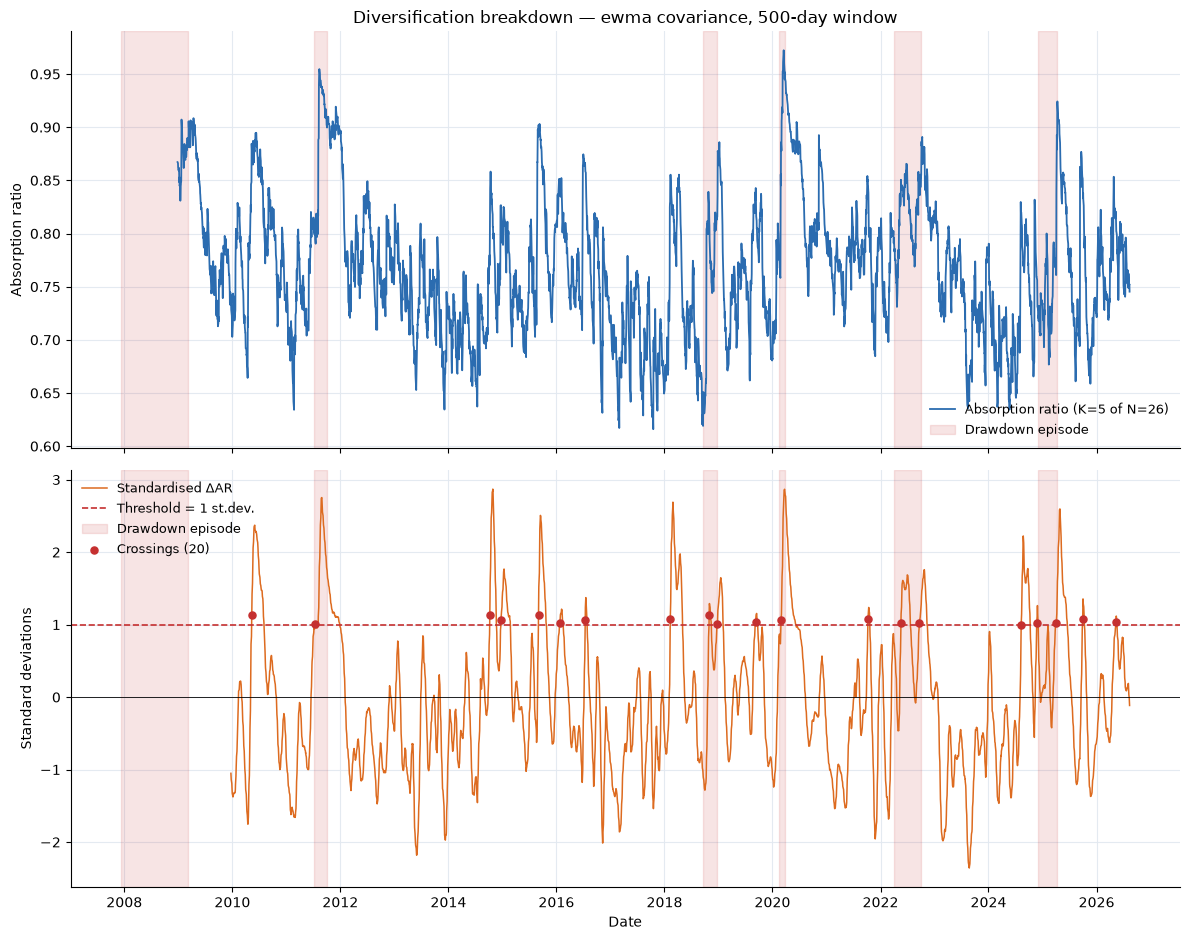

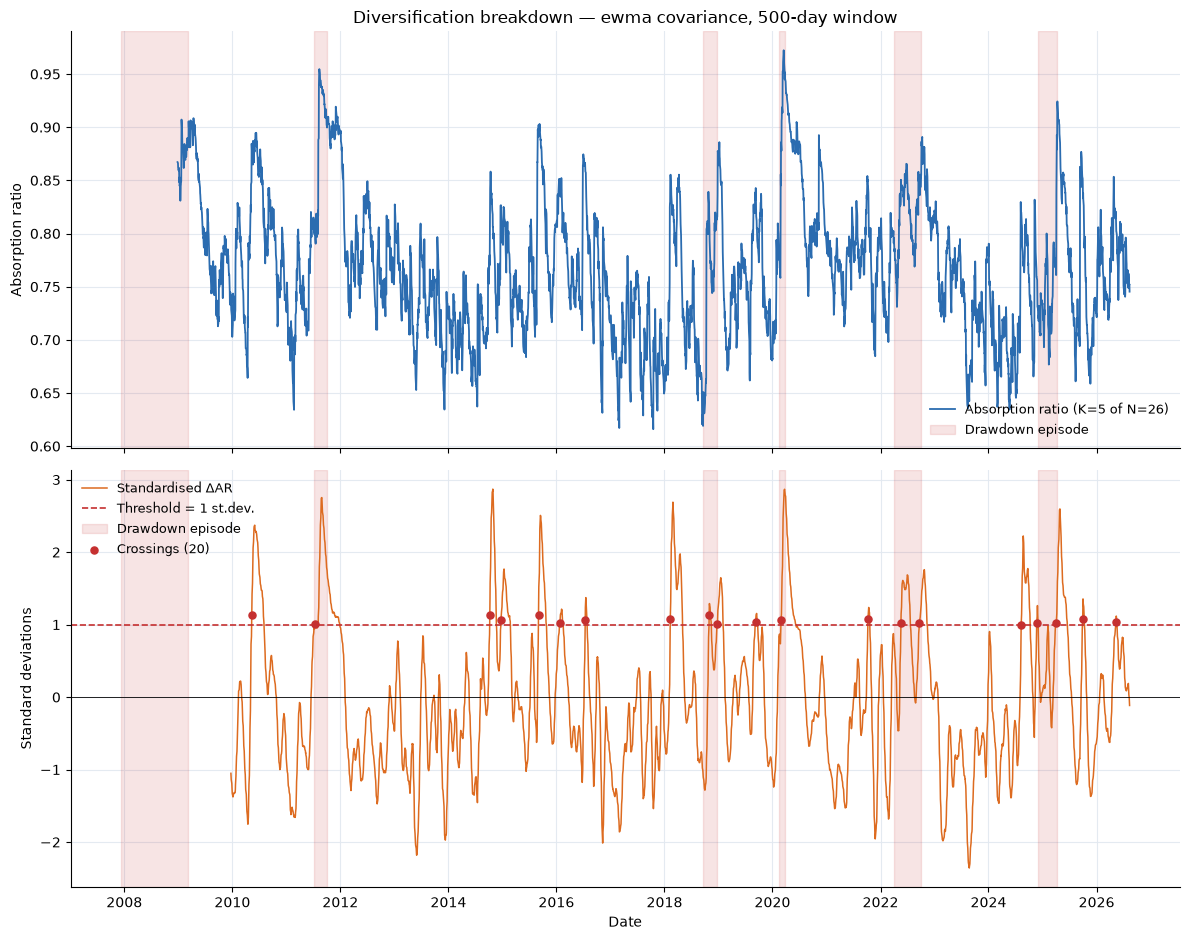

In [10]:
from risk_engine.report import plot_absorption_ratio, plot_regime_probabilities

fig = plot_absorption_ratio(ewma, events=events, signal=signal,
                            crossings=crossings, threshold=1.0)
fig

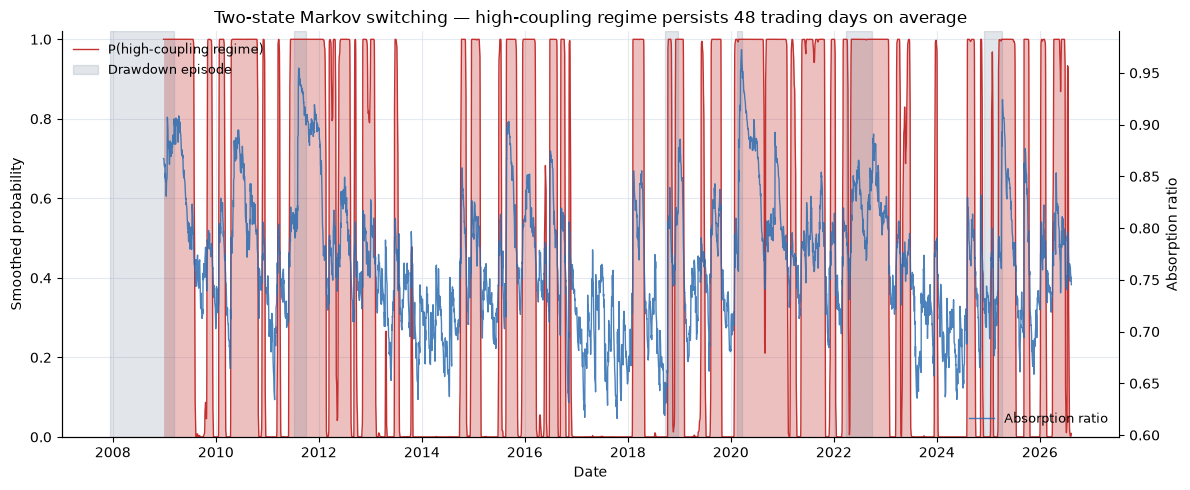

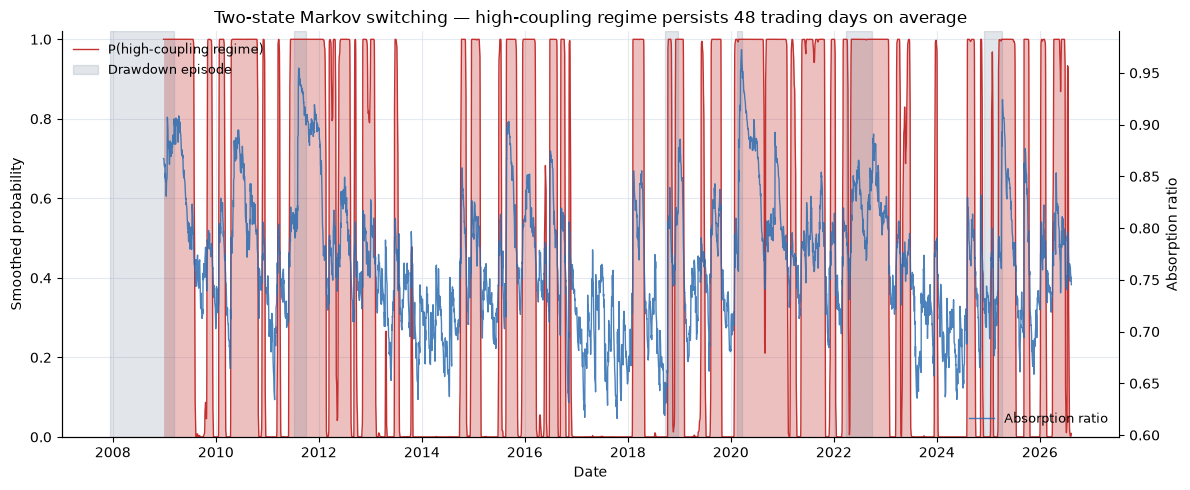

In [11]:
plot_regime_probabilities(regimes, absorption=ewma.absorption, events=events)

## What this is actually good for

Concentration measurement, not forecasting.

*"How much of my risk is really one trade today?"* is a question the VaR number does not
answer, and the effective-bet count answers it in a form a risk committee can act on:
26 positions, 8.5 bets, 1.9 in a crisis. Position limits and hedge sizing can use that.

What it does not support is a claim about what happens next. Publishing it as if it did
would have been the easy version of this write-up — and the first competent reader to
rerun it with a volatility benchmark would have found the same thing I did.

**Caveats**, stated plainly:

- **Survivorship bias** — 26 names liquid *today*, back-filled to 2007.
- **The event study is generous to the signal** — it credits the earliest qualifying
  crossing inside the horizon, the most favourable reading, and absorption still loses.
- **The covariance choice dominates** — the rolling sample covariance scores 0 hits at
  every threshold; it is simply too slow to react.
- **Only 5 evaluable events** — a small sample, which is why the sensitivity grid
  matters more than any single cell.